# 국내 여행로그 데이터 서부권 샘플 EDA

목표는 2023년 서부권 샘플 데이터에서 여행자들이 어떤 여행지를 선택하는지 이해하는 것입니다. 방문지 정보를 중심으로 여행, 여행자, 활동, 이동, 소비, 사진, GPS, 코드/시군구 데이터를 연결해 지역, 방문지 유형, 선택 이유, 만족도, 여정 흐름을 살펴봅니다.

기본 데이터 경로는 `../../data/raw/west/sample`입니다.

## 1. 환경 설정

In [1]:
from pathlib import Path
from contextlib import redirect_stderr
from io import StringIO

import numpy as np
import pandas as pd
try:
    with redirect_stderr(StringIO()):
        import matplotlib.pyplot as plt
    HAS_PLOT = True
except Exception as exc:
    plt = None
    HAS_PLOT = False
    print(f"matplotlib import failed; charts will fall back to tables. reason={exc}")

try:
    with redirect_stderr(StringIO()):
        import seaborn as sns
    if HAS_PLOT:
        sns.set_theme(style="whitegrid")
except Exception:
    sns = None
    if HAS_PLOT:
        try:
            plt.style.use("seaborn-v0_8-whitegrid")
        except Exception:
            pass

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 50)

if HAS_PLOT:
    plt.rcParams["figure.figsize"] = (10, 5)
    plt.rcParams["font.family"] = ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = Path("../../data/raw/west/sample")
CSV_DIR = DATA_DIR / "csv"
GPS_DIR = DATA_DIR / "gps_data"

assert CSV_DIR.exists(), f"CSV directory not found: {CSV_DIR.resolve()}"
assert GPS_DIR.exists(), f"GPS directory not found: {GPS_DIR.resolve()}"

DATA_DIR.resolve()

WindowsPath('S:/Study/kor_travel_recommendation/data/raw/west/sample')

## 2. 유틸리티 함수

In [2]:
CSV_ALIASES = {
    "tc_codea": "codea",
    "tc_codeb": "codeb",
    "tc_sgg": "sgg",
    "tn_activity_consume_his": "activity_consume",
    "tn_activity_his": "activity",
    "tn_adv_consume_his": "adv_consume",
    "tn_companion_info": "companion",
    "tn_lodge_consume_his": "lodge_consume",
    "tn_move_his": "move",
    "tn_mvmn_consume_his": "movement_consume",
    "tn_tour_photo": "photo",
    "tn_traveller_master": "traveller",
    "tn_travel": "travel",
    "tn_visit_area_info": "visit",
}


def infer_key(path: Path) -> str:
    stem = path.stem
    for prefix, key in sorted(CSV_ALIASES.items(), key=lambda x: len(x[0]), reverse=True):
        if stem.startswith(prefix):
            return key
    return stem


def load_csvs(base_dir: Path) -> dict[str, pd.DataFrame]:
    frames = {}
    for path in sorted(base_dir.glob("*.csv")):
        frames[infer_key(path)] = pd.read_csv(path, encoding="utf-8")
    return frames


def summarize_df(df: pd.DataFrame) -> pd.DataFrame:
    summary = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "missing": df.isna().sum(),
        "missing_rate": df.isna().mean().round(3),
        "n_unique": df.nunique(dropna=True),
    })
    return summary.sort_values(["missing_rate", "n_unique"], ascending=[False, False])


def clean_code_value(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text.endswith(".0"):
        text = text[:-2]
    return text


def make_code_map(codeb: pd.DataFrame, cd_a: str) -> dict[str, str]:
    sub = codeb.loc[codeb["cd_a"].eq(cd_a), ["cd_b", "cd_nm"]].copy()
    sub["cd_b"] = sub["cd_b"].map(clean_code_value)
    return sub.dropna(subset=["cd_b"]).set_index("cd_b")["cd_nm"].to_dict()


def add_code_label(df: pd.DataFrame, col: str, code_map: dict[str, str], label_col: str) -> pd.DataFrame:
    out = df.copy()
    if col not in out.columns:
        out[label_col] = np.nan
        return out
    out[label_col] = out[col].map(clean_code_value).map(code_map)
    return out


def plot_top_counts(df: pd.DataFrame, col: str, title: str, n: int = 15):
    if col not in df.columns:
        print(f"Column not found: {col}")
        return None
    counts = df[col].dropna().astype(str).value_counts().head(n)
    if counts.empty:
        print(f"No non-null values to plot: {col}")
        return None
    if not HAS_PLOT:
        return counts.rename("count").to_frame()
    ax = counts.sort_values().plot(kind="barh")
    ax.set_title(title)
    ax.set_xlabel("count")
    ax.set_ylabel("")
    plt.tight_layout()
    return ax


def normalize_id(series: pd.Series) -> pd.Series:
    return series.astype("string").str.replace(r"\.0$", "", regex=True).str.strip()


def numeric_series(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")

## 3. 데이터 로딩과 기본 점검
---
결과 
* 방문지 : 3,554
* 여행 : 320건
* 여행자 : 320명
* 활동 : 4,075건 
* 이동 3,554건
* 사진 1,818건
* 활동 소비 : 2,095건
---
해석 
* 각기 다른 320명의 여행자별 한 번씩 여행 기록 데이터 
* 방문 - 활동 - 소비 흐름 파악 가능


In [3]:
csvs = load_csvs(CSV_DIR)
gps_files = sorted(GPS_DIR.glob("*.csv"))

dataset_summary = pd.DataFrame([
    {"key": key, "rows": len(df), "cols": df.shape[1], "columns": ", ".join(df.columns[:8])}
    for key, df in csvs.items()
]).sort_values("key")

gps_summary = pd.DataFrame([
    {"file": path.name, "rows": sum(1 for _ in path.open(encoding="utf-8")) - 1}
    for path in gps_files
])

dataset_summary

,key,rows,cols,columns
4,activity,4075,9,"TRAVEL_ID, VISIT_AREA_ID, ACTIVITY_TYPE_CD, AC..."
3,activity_consume,2095,18,"TRAVEL_ID, VISIT_AREA_ID, ACTIVITY_TYPE_CD, AC..."
5,adv_consume,79,15,"TRAVEL_ID, ADV_NM, ADV_SEQ, PAYMENT_NUM, BRNO,..."
0,codea,30,12,"idx, cd_a, cd_nm, cd_memo, cd_memo2, del_flag,..."
1,codeb,238,10,"idx, cd_a, cd_b, cd_nm, cd_memo, cd_memo2, del..."
6,companion,493,6,"COMPANION_SEQ, TRAVEL_ID, REL_CD, COMPANION_GE..."
7,lodge_consume,168,18,"TRAVEL_ID, LODGING_NM, LODGING_PAYMENT_SEQ, LO..."
8,move,3554,8,"TRAVEL_ID, TRIP_ID, START_VISIT_AREA_ID, END_V..."
9,movement_consume,706,13,"TRAVEL_ID, MVMN_SE, PAYMENT_SE, PAYMENT_SEQ, M..."
10,photo,1818,12,"TRAVEL_ID, VISIT_AREA_ID, TOUR_PHOTO_SEQ, PHOT..."


In [4]:
gps_summary

,file,rows
0,tn_gps_coord_g_g000297.csv,21309
1,tn_gps_coord_g_g000303.csv,3616
2,tn_gps_coord_g_g000325.csv,41601


In [5]:
visit = csvs["visit"].copy()
travel = csvs["travel"].copy()
traveller = csvs["traveller"].copy()
codeb = csvs["codeb"].copy()
sgg = csvs["sgg"].copy()

print("visit", visit.shape)
print("travel", travel.shape)
print("traveller", traveller.shape)
visit.head()

visit (3554, 23)
travel (320, 10)
traveller (320, 36)


,VISIT_AREA_ID,TRAVEL_ID,VISIT_ORDER,VISIT_AREA_NM,VISIT_START_YMD,VISIT_END_YMD,ROAD_NM_ADDR,LOTNO_ADDR,X_COORD,Y_COORD,ROAD_NM_CD,LOTNO_CD,POI_ID,POI_NM,RESIDENCE_TIME_MIN,VISIT_AREA_TYPE_CD,REVISIT_YN,VISIT_CHC_REASON_CD,LODGING_TYPE_CD,DGSTFN,REVISIT_INTENTION,RCMDTN_INTENTION,SGG_CD
0,2305190001,e_e000658,1,집,2023-05-19,2023-05-19,충렬대로446번길 67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21,NaN,NaN,NaN,NaN,NaN,NaN,2.626010e+09
1,2305190002,e_e000658,2,부산역,2023-05-19,2023-05-19,부산 동구 중앙대로 206,부산 동구 초량동 1187-1,129.041419,35.115109,NaN,NaN,POI01000TR040141V,부산역,0.0,9,Y,6.0,NaN,5.0,5.0,5.0,NaN
2,2305190003,e_e000658,3,천안아산역,2023-05-19,2023-05-19,충남 아산시 배방읍 희망로 100,충남 아산시 배방읍 장재리 305,127.104380,36.794603,NaN,NaN,POI0100000079D3KC,천안아산역,0.0,9,Y,6.0,NaN,5.0,5.0,5.0,NaN
3,2305190004,e_e000658,4,통발 집,2023-05-19,2023-05-19,충남 천안시 서북구 불당21로 67-18,충남 천안시 서북구 불당동 1536-2,127.108495,36.814018,NaN,NaN,POI01000000D1HIT2,통발집,30.0,11,N,5.0,NaN,5.0,5.0,5.0,NaN
4,2305190005,e_e000658,5,사네,2023-05-19,2023-05-19,충남 아산시 음봉면 음봉로586번길 77-20,충남 아산시 음봉면 덕지리 264-3,127.068563,36.831275,NaN,NaN,POI01000000F00XHP,사네테라스,90.0,11,N,5.0,NaN,5.0,5.0,5.0,NaN


## 4. 코드 매핑

In [6]:
code_maps = {
    "VIS": make_code_map(codeb, "VIS"),
    "REN": make_code_map(codeb, "REN"),
    "ACT": make_code_map(codeb, "ACT"),
    "MOV": make_code_map(codeb, "MOV"),
    "HTY": make_code_map(codeb, "HTY"),
    "DGS": make_code_map(codeb, "DGS"),
    "REC": make_code_map(codeb, "REC"),
    "REV": make_code_map(codeb, "REV"),
    "REL": make_code_map(codeb, "REL"),
    "TSY": make_code_map(codeb, "TSY"),
    "TMT": make_code_map(codeb, "TMT"),
    "TTY": make_code_map(codeb, "TTY"),
    "MIS": make_code_map(codeb, "MIS"),
    "TAR": make_code_map(codeb, "TAR"),
    "GEN": make_code_map(codeb, "GEN"),
    "AGE": make_code_map(codeb, "AGE"),
    "INC": make_code_map(codeb, "INC"),
    "EDU": make_code_map(codeb, "EDU"),
    "MAR": make_code_map(codeb, "MAR"),
    "JOB": make_code_map(codeb, "JOB"),
    "TCR": make_code_map(codeb, "TCR"),
}

pd.DataFrame([
    {"code": code, "n_labels": len(labels), "sample": dict(list(labels.items())[:5])}
    for code, labels in code_maps.items()
])

,code,n_labels,sample
0,VIS,17,"{'21': '집', '22': '친구/친지집', '23': '사무실', '24':..."
1,REN,11,"{'1': '지명도/명소/핫플레이스', '2': '온라인(SNS, 블로그 등) 평가..."
2,ACT,8,"{'1': '취식', '2': '쇼핑 / 구매', '3': '체험 활동 / 입장 및..."
3,MOV,17,"{'11': '관광버스', '12': '시외/고속버스', '13': '시내/마을버스..."
4,HTY,12,"{'1': '호텔', '2': '모텔/여관', '3': '펜션', '4': '콘도미..."
5,DGS,5,"{'1': '매우 불만족', '2': '불만족', '3': '보통', '4': '만..."
6,REC,5,"{'1': '전혀 그렇지 않다', '2': '그렇지 않다', '3': '보통', '..."
7,REV,2,"{'1': '처음 방문', '2': '재방문'}"
8,REL,0,{}


In [7]:
visit_labeled = visit.copy()
visit_labeled = add_code_label(visit_labeled, "VISIT_AREA_TYPE_CD", code_maps["VIS"], "VISIT_AREA_TYPE_NM")
visit_labeled = add_code_label(visit_labeled, "VISIT_CHC_REASON_CD", code_maps["REN"], "VISIT_CHC_REASON_NM")
visit_labeled = add_code_label(visit_labeled, "LODGING_TYPE_CD", code_maps["HTY"], "LODGING_TYPE_NM")
visit_labeled = add_code_label(visit_labeled, "DGSTFN", code_maps["DGS"], "DGSTFN_NM")
visit_labeled = add_code_label(visit_labeled, "REVISIT_INTENTION", code_maps["REC"], "REVISIT_INTENTION_NM")
visit_labeled = add_code_label(visit_labeled, "RCMDTN_INTENTION", code_maps["REC"], "RCMDTN_INTENTION_NM")

mapping_check = []
for col, label_col in [
    ("VISIT_AREA_TYPE_CD", "VISIT_AREA_TYPE_NM"),
    ("VISIT_CHC_REASON_CD", "VISIT_CHC_REASON_NM"),
    ("LODGING_TYPE_CD", "LODGING_TYPE_NM"),
    ("DGSTFN", "DGSTFN_NM"),
    ("REVISIT_INTENTION", "REVISIT_INTENTION_NM"),
    ("RCMDTN_INTENTION", "RCMDTN_INTENTION_NM"),
]:
    has_code = visit_labeled[col].notna() if col in visit_labeled.columns else pd.Series(False, index=visit_labeled.index)
    unmapped = has_code & visit_labeled[label_col].isna()
    mapping_check.append({
        "code_col": col,
        "coded_rows": int(has_code.sum()),
        "unmapped_rows": int(unmapped.sum()),
        "unmapped_values": sorted(visit_labeled.loc[unmapped, col].dropna().astype(str).unique())[:10],
    })

pd.DataFrame(mapping_check)

,code_col,coded_rows,unmapped_rows,unmapped_values
0,VISIT_AREA_TYPE_CD,3554,0,[]
1,VISIT_CHC_REASON_CD,2855,0,[]
2,LODGING_TYPE_CD,282,0,[]
3,DGSTFN,2853,0,[]
4,REVISIT_INTENTION,2853,0,[]
5,RCMDTN_INTENTION,2853,0,[]


## 5. 방문지 중심 분석 테이블 생성

In [8]:
for df in [visit_labeled, travel, traveller]:
    for col in ["TRAVEL_ID", "TRAVELER_ID", "VISIT_AREA_ID"]:
        if col in df.columns:
            df[col] = normalize_id(df[col])

sgg_small = sgg.copy()
sgg_small["SGG_CD"] = normalize_id(sgg_small["SGG_CD"])
sgg_small = sgg_small[["SGG_CD", "SIDO_NM", "SGG_NM", "DONG_NM", "RI_NM"]].drop_duplicates("SGG_CD")

visit_labeled["SGG_CD"] = normalize_id(visit_labeled["SGG_CD"])
visit_mart = (
    visit_labeled
    .merge(travel, on="TRAVEL_ID", how="left", suffixes=("", "_TRAVEL"))
    .merge(traveller, on="TRAVELER_ID", how="left", suffixes=("", "_TRAVELER"))
    .merge(sgg_small, on="SGG_CD", how="left")
)

for col in ["VISIT_ORDER", "RESIDENCE_TIME_MIN", "X_COORD", "Y_COORD", "DGSTFN", "REVISIT_INTENTION", "RCMDTN_INTENTION"]:
    if col in visit_mart.columns:
        visit_mart[col] = numeric_series(visit_mart[col])

visit_mart["VISIT_START_YMD"] = pd.to_datetime(visit_mart["VISIT_START_YMD"], errors="coerce")
visit_mart["VISIT_END_YMD"] = pd.to_datetime(visit_mart["VISIT_END_YMD"], errors="coerce")
visit_mart["TRAVEL_START_YMD"] = pd.to_datetime(visit_mart["TRAVEL_START_YMD"], errors="coerce")
visit_mart["TRAVEL_END_YMD"] = pd.to_datetime(visit_mart["TRAVEL_END_YMD"], errors="coerce")

join_check = pd.DataFrame({
    "metric": ["visit_rows_before", "visit_rows_after", "unique_visit_area", "unique_travel", "unique_traveler"],
    "value": [len(visit_labeled), len(visit_mart), visit_mart["VISIT_AREA_ID"].nunique(), visit_mart["TRAVEL_ID"].nunique(), visit_mart["TRAVELER_ID"].nunique()],
})
join_check

,metric,value
0,visit_rows_before,3554
1,visit_rows_after,3554
2,unique_visit_area,1095
3,unique_travel,320
4,unique_traveler,320


In [9]:
assert len(visit_mart) == len(visit_labeled), "Join expanded or dropped visit rows unexpectedly"
visit_mart.head()

,VISIT_AREA_ID,TRAVEL_ID,VISIT_ORDER,VISIT_AREA_NM,VISIT_START_YMD,VISIT_END_YMD,ROAD_NM_ADDR,LOTNO_ADDR,X_COORD,Y_COORD,ROAD_NM_CD,LOTNO_CD,POI_ID,POI_NM,RESIDENCE_TIME_MIN,VISIT_AREA_TYPE_CD,REVISIT_YN,VISIT_CHC_REASON_CD,LODGING_TYPE_CD,DGSTFN,REVISIT_INTENTION,RCMDTN_INTENTION,SGG_CD,VISIT_AREA_TYPE_NM,VISIT_CHC_REASON_NM,LODGING_TYPE_NM,DGSTFN_NM,REVISIT_INTENTION_NM,RCMDTN_INTENTION_NM,TRAVEL_NM,TRAVELER_ID,TRAVEL_PURPOSE,TRAVEL_START_YMD,TRAVEL_END_YMD,MVMN_NM,TRAVEL_PERSONA,TRAVEL_MISSION,TRAVEL_MISSION_CHECK,RESIDENCE_SGG_CD,GENDER,AGE_GRP,EDU_NM,EDU_FNSH_SE,MARR_STTS,FAMILY_MEMB,JOB_NM,JOB_ETC,INCOME,HOUSE_INCOME,TRAVEL_TERM,TRAVEL_NUM,TRAVEL_LIKE_SIDO_1,TRAVEL_LIKE_SGG_1,TRAVEL_LIKE_SIDO_2,TRAVEL_LIKE_SGG_2,TRAVEL_LIKE_SIDO_3,TRAVEL_LIKE_SGG_3,TRAVEL_STYL_1,TRAVEL_STYL_2,TRAVEL_STYL_3,TRAVEL_STYL_4,TRAVEL_STYL_5,TRAVEL_STYL_6,TRAVEL_STYL_7,TRAVEL_STYL_8,TRAVEL_STATUS_RESIDENCE,TRAVEL_STATUS_DESTINATION,TRAVEL_STATUS_ACCOMPANY,TRAVEL_STATUS_YMD,TRAVEL_MOTIVE_1,TRAVEL_MOTIVE_2,TRAVEL_MOTIVE_3,TRAVEL_COMPANIONS_NUM,SIDO_NM,SGG_NM,DONG_NM,RI_NM
0,2305190001,e_e000658,1,집,2023-05-19,2023-05-19,충렬대로446번길 67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21,NaN,NaN,NaN,NaN,NaN,NaN,2626010200,집,NaN,NaN,NaN,NaN,NaN,E01,e000658,21;22;24;26;7,2023-05-19,2023-05-22,대중교통 등,충청권 방문/충청권 외 거주/39세 이하/3인 이상 친구/일반미션,21;22;24;26;7,22;26;3,26,남,30,6,1,1,1,3,NaN,5,NaN,3,4,29,29155,11,11680,50,50110,4,6,3,7,3,2,5,3,부산광역시,서울,3인 이상 여행(가족 외),2023-05-19~2023-05-21,9,5.0,1.0,5,부산광역시,동래구,안락동,NaN
1,2305190002,e_e000658,2,부산역,2023-05-19,2023-05-19,부산 동구 중앙대로 206,부산 동구 초량동 1187-1,129.041419,35.115109,NaN,NaN,POI01000TR040141V,부산역,0.0,9,Y,6.0,NaN,5.0,5.0,5.0,<NA>,"역, 터미널, 고속도로 휴게소",가기 편해서/교통이 좋아서,NaN,매우만족,매우 그렇다,매우 그렇다,E01,e000658,21;22;24;26;7,2023-05-19,2023-05-22,대중교통 등,충청권 방문/충청권 외 거주/39세 이하/3인 이상 친구/일반미션,21;22;24;26;7,22;26;3,26,남,30,6,1,1,1,3,NaN,5,NaN,3,4,29,29155,11,11680,50,50110,4,6,3,7,3,2,5,3,부산광역시,서울,3인 이상 여행(가족 외),2023-05-19~2023-05-21,9,5.0,1.0,5,NaN,NaN,NaN,NaN
2,2305190003,e_e000658,3,천안아산역,2023-05-19,2023-05-19,충남 아산시 배방읍 희망로 100,충남 아산시 배방읍 장재리 305,127.104380,36.794603,NaN,NaN,POI0100000079D3KC,천안아산역,0.0,9,Y,6.0,NaN,5.0,5.0,5.0,<NA>,"역, 터미널, 고속도로 휴게소",가기 편해서/교통이 좋아서,NaN,매우만족,매우 그렇다,매우 그렇다,E01,e000658,21;22;24;26;7,2023-05-19,2023-05-22,대중교통 등,충청권 방문/충청권 외 거주/39세 이하/3인 이상 친구/일반미션,21;22;24;26;7,22;26;3,26,남,30,6,1,1,1,3,NaN,5,NaN,3,4,29,29155,11,11680,50,50110,4,6,3,7,3,2,5,3,부산광역시,서울,3인 이상 여행(가족 외),2023-05-19~2023-05-21,9,5.0,1.0,5,NaN,NaN,NaN,NaN
3,2305190004,e_e000658,4,통발 집,2023-05-19,2023-05-19,충남 천안시 서북구 불당21로 67-18,충남 천안시 서북구 불당동 1536-2,127.108495,36.814018,NaN,NaN,POI01000000D1HIT2,통발집,30.0,11,N,5.0,NaN,5.0,5.0,5.0,<NA>,식당/카페,지인의 추천이 있어서,NaN,매우만족,매우 그렇다,매우 그렇다,E01,e000658,21;22;24;26;7,2023-05-19,2023-05-22,대중교통 등,충청권 방문/충청권 외 거주/39세 이하/3인 이상 친구/일반미션,21;22;24;26;7,22;26;3,26,남,30,6,1,1,1,3,NaN,5,NaN,3,4,29,29155,11,11680,50,50110,4,6,3,7,3,2,5,3,부산광역시,서울,3인 이상 여행(가족 외),2023-05-19~2023-05-21,9,5.0,1.0,5,NaN,NaN,NaN,NaN
4,2305190005,e_e000658,5,사네,2023-05-19,2023-05-19,충남 아산시 음봉면 음봉로586번길 77-20,충남 아산시 음봉면 덕지리 264-3,127.068563,36.831275,NaN,NaN,POI01000000F00XHP,사네테라스,90.0,11,N,5.0,NaN,5.0,5.0,5.0,<NA>,식당/카페,지인의 추천이 있어서,NaN,매우만족,매우 그렇다,매우 그렇다,E01,e000658,21;22;24;26;7,2023-05-19,2023-05-22,대중교통 등,충청권 방문/충청권 외 거주/39세 이하/3인 이상 친구/일반미션,21;22;24;26;7,22;26;3,26,남,30,6,1,1,1,3,NaN,5,NaN,3,4,29,29155,11,11680,50,50110,4,6,3,7,3,2,5,3,부산광역시,서울,3인 이상 여행(가족 외),2023-05-19~2023-05-21,9,5.0,1.0,5,NaN,NaN,NaN,NaN


## 6. 방문지 선택 패턴
---
결과
* 많이 선택된 유형은 식당/카페, 집, 역/터미널/휴게소, 상업지구, 숙소
* 평균 만족도는 4.30/5, 재방문 의향은 4.09/5, 추천의향은 4.19/5
---
해석
* 여행 로그라 실제 관광지만이 아니라 출발지/교통/식사 지점도 집계됨 
* 전반적으로 평가 높게 했음 median이 대부분 4

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

<Axes: title={'center': '방문지 유형 Top 15'}, xlabel='count'>

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

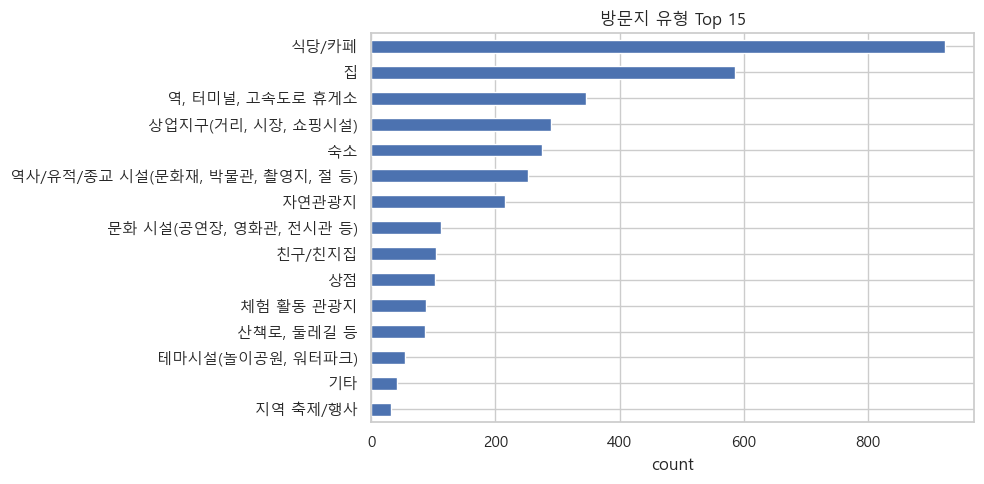

In [10]:
plot_top_counts(visit_mart, "VISIT_AREA_TYPE_NM", "방문지 유형 Top 15")

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

<Axes: title={'center': '방문지 선택 이유'}, xlabel='count'>

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

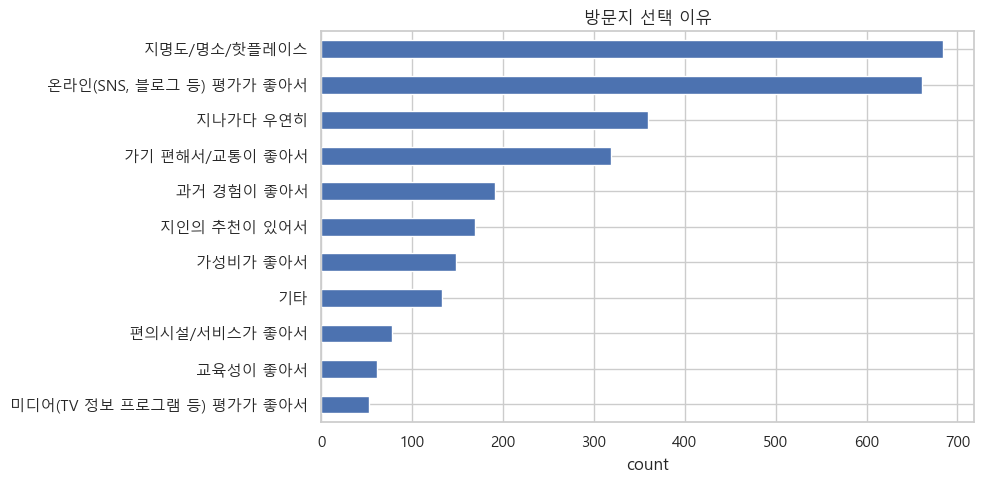

In [11]:
plot_top_counts(visit_mart, "VISIT_CHC_REASON_NM", "방문지 선택 이유")

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

<Axes: title={'center': '방문 지역: 시도'}, xlabel='count'>

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

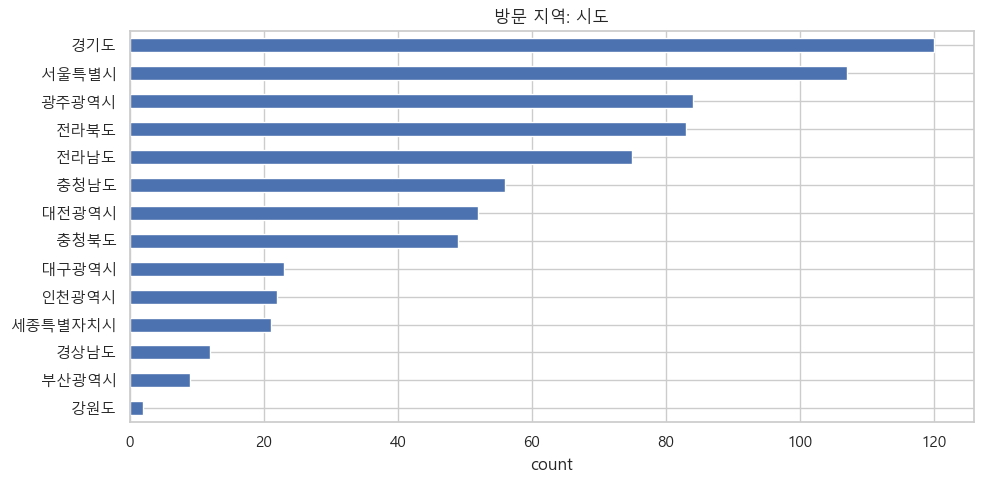

In [12]:
plot_top_counts(visit_mart, "SIDO_NM", "방문 지역: 시도")

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

<Axes: title={'center': '방문지명 Top 20'}, xlabel='count'>

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

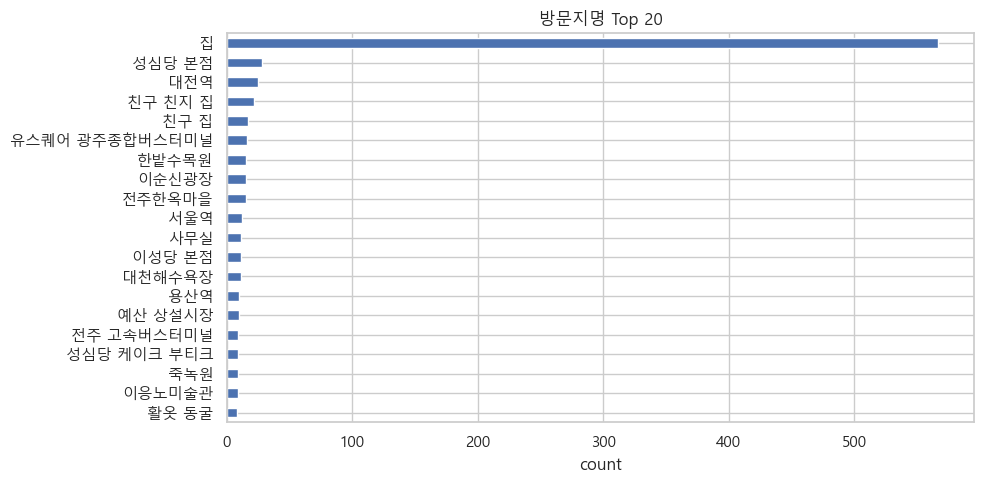

In [13]:
plot_top_counts(visit_mart, "VISIT_AREA_NM", "방문지명 Top 20", n=20)

In [14]:
score_cols = ["DGSTFN", "REVISIT_INTENTION", "RCMDTN_INTENTION"]
score_summary = visit_mart[score_cols].describe().T
score_summary

,count,mean,std,min,25%,50%,75%,max
DGSTFN,2853.0,4.299334,0.817577,1.0,4.0,4.0,5.0,5.0
REVISIT_INTENTION,2853.0,4.085174,1.015017,1.0,3.0,4.0,5.0,5.0
RCMDTN_INTENTION,2853.0,4.185769,0.924867,1.0,4.0,4.0,5.0,5.0


In [15]:
score_by_type = (
    visit_mart.dropna(subset=["VISIT_AREA_TYPE_NM"])
    .groupby("VISIT_AREA_TYPE_NM")
    .agg(
        visits=("VISIT_AREA_ID", "count"),
        avg_stay_min=("RESIDENCE_TIME_MIN", "mean"),
        avg_satisfaction=("DGSTFN", "mean"),
        avg_recommend=("RCMDTN_INTENTION", "mean"),
    )
    .sort_values("visits", ascending=False)
)
score_by_type.head(15)

,visits,avg_stay_min,avg_satisfaction,avg_recommend
VISIT_AREA_TYPE_NM,,,,
식당/카페,924,54.285714,4.339827,4.202381
집,585,320.808081,NaN,NaN
"역, 터미널, 고속도로 휴게소",346,27.572254,4.193642,4.092486
"상업지구(거리, 시장, 쇼핑시설)",289,51.176471,4.166090,4.013841
숙소,275,262.145455,4.345455,4.192727
"역사/유적/종교 시설(문화재, 박물관, 촬영지, 절 등)",252,54.880952,4.277778,4.206349
자연관광지,216,70.277778,4.356481,4.310185
"문화 시설(공연장, 영화관, 전시관 등)",112,76.607143,4.330357,4.267857
친구/친지집,104,215.487805,4.400000,3.800000


## 7. 여행자 특성과 방문지 선택
---
결과
* 여성 방문 로드 더 많음
* 연령대는 20~40대 중심 
* 평균 동반자 수 약 1.52명
* med 동반자 수 1명
* 모든 연령대에서 식당/카페 비중이 가장 큼
*  20대는 역/터미널 비중이 비교적 높고, 40-50대는 자연관광지·역사/유적 비중이 조금 올라감
---
해석
* 20~40대 혼자 또는 소규모 동행 여행 중심 데이터이다
* 20대는 역/터미널 활발하게 이용해 여행한다
* 4050은 자연, 역사 여행 중심으로

In [16]:
traveler_cols = ["GENDER", "AGE_GRP", "INCOME", "HOUSE_INCOME", "TRAVEL_COMPANIONS_NUM"]
visit_mart[traveler_cols].describe(include="all")

,GENDER,AGE_GRP,INCOME,HOUSE_INCOME,TRAVEL_COMPANIONS_NUM
count,3554,3554.000000,3554.000000,2660.000000,3554.000000
unique,2,NaN,NaN,NaN,NaN
top,여,NaN,NaN,NaN,NaN
freq,1979,NaN,NaN,NaN,NaN
mean,NaN,31.941474,3.638154,7.484211,1.523917
std,NaN,11.798618,1.812229,2.464058,1.503394
min,NaN,20.000000,1.000000,1.000000,0.000000
25%,NaN,20.000000,2.000000,6.000000,1.000000
50%,NaN,30.000000,4.000000,7.000000,1.000000
75%,NaN,40.000000,5.000000,9.000000,2.000000


In [17]:
type_by_age = pd.crosstab(
    visit_mart["AGE_GRP"],
    visit_mart["VISIT_AREA_TYPE_NM"],
    normalize="index",
).round(3)
type_by_age

VISIT_AREA_TYPE_NM,기타,"레저/스포츠 관련 시설(스키, 카트, 수상레저)","문화 시설(공연장, 영화관, 전시관 등)",사무실,"산책로, 둘레길 등","상업지구(거리, 시장, 쇼핑시설)",상점,숙소,식당/카페,"역, 터미널, 고속도로 휴게소","역사/유적/종교 시설(문화재, 박물관, 촬영지, 절 등)",자연관광지,지역 축제/행사,집,체험 활동 관광지,친구/친지집,"테마시설(놀이공원, 워터파크)"
AGE_GRP,,,,,,,,,,,,,,,,,
20,0.016,0.007,0.033,0.005,0.029,0.080,0.034,0.064,0.279,0.129,0.053,0.050,0.012,0.153,0.016,0.034,0.006
30,0.010,0.009,0.031,0.004,0.018,0.098,0.024,0.075,0.269,0.090,0.061,0.062,0.006,0.172,0.021,0.036,0.016
40,0.006,0.011,0.025,0.006,0.027,0.072,0.021,0.107,0.231,0.063,0.084,0.081,0.008,0.174,0.034,0.017,0.034
50,0.017,0.003,0.041,0.008,0.017,0.075,0.041,0.072,0.213,0.064,0.122,0.055,0.008,0.177,0.047,0.033,0.008
60,0.006,0.011,0.033,0.000,0.033,0.050,0.028,0.077,0.282,0.110,0.105,0.066,0.011,0.144,0.028,0.000,0.017


In [18]:
purpose_long = (
    travel[["TRAVEL_ID", "TRAVEL_PURPOSE"]]
    .dropna()
    .assign(TRAVEL_PURPOSE=lambda d: d["TRAVEL_PURPOSE"].astype(str).str.split(";"))
    .explode("TRAVEL_PURPOSE")
)
purpose_long["TRAVEL_PURPOSE"] = purpose_long["TRAVEL_PURPOSE"].map(clean_code_value)

purpose_visit = visit_mart[["TRAVEL_ID", "VISIT_AREA_TYPE_NM", "VISIT_CHC_REASON_NM"]].merge(purpose_long, on="TRAVEL_ID", how="left")
purpose_visit.groupby("TRAVEL_PURPOSE").agg(
    visits=("TRAVEL_ID", "count"),
    top_type=("VISIT_AREA_TYPE_NM", lambda s: s.dropna().mode().iat[0] if not s.dropna().mode().empty else np.nan),
    top_reason=("VISIT_CHC_REASON_NM", lambda s: s.dropna().mode().iat[0] if not s.dropna().mode().empty else np.nan),
).sort_values("visits", ascending=False).head(20)

,visits,top_type,top_reason
TRAVEL_PURPOSE,,,
22,2091,식당/카페,지명도/명소/핫플레이스
1,1446,식당/카페,지명도/명소/핫플레이스
2,1294,식당/카페,"온라인(SNS, 블로그 등) 평가가 좋아서"
3,1219,식당/카페,지명도/명소/핫플레이스
6,1175,식당/카페,지명도/명소/핫플레이스
4,1172,식당/카페,지명도/명소/핫플레이스
21,1158,식당/카페,"온라인(SNS, 블로그 등) 평가가 좋아서"
24,973,식당/카페,"온라인(SNS, 블로그 등) 평가가 좋아서"
26,723,식당/카페,지명도/명소/핫플레이스


## 8. 여정 흐름과 이동 패턴
---
결과
* 1번째 방문지 집이 우세, 2번째 방문지 역/터미널/휴게소, 3번째 이후 식당/카페 우세
* 이동은 자가용 1,718건, 도보 813건
* 가장 긴 GPS 기록은 g_g000325로 2023-05-22부터 2023-05-24까지 기록
---
해석
* 출발지 -> 교통 거점 -> 식사/카페 -> 주요 방문지 템플릿 적절함 
* 서부권 여행은 차량 기반 여행이 중요함
* 이 데이터에서 가장 긴 여행은 2박 3일 

In [19]:
order_summary = visit_mart.groupby("VISIT_ORDER").agg(
    visits=("VISIT_AREA_ID", "count"),
    top_type=("VISIT_AREA_TYPE_NM", lambda s: s.dropna().mode().iat[0] if not s.dropna().mode().empty else np.nan),
    avg_stay_min=("RESIDENCE_TIME_MIN", "mean"),
).sort_index()
order_summary.head(20)

,visits,top_type,avg_stay_min
VISIT_ORDER,,,
1,320,집,NaN
2,320,"역, 터미널, 고속도로 휴게소",65.156250
3,320,식당/카페,69.750000
4,315,식당/카페,102.857143
5,307,식당/카페,116.188925
6,279,식당/카페,114.516129
7,249,식당/카페,115.180723
8,216,식당/카페,116.111111
9,194,식당/카페,106.546392


In [20]:
move = csvs["move"].copy()
for col in ["TRAVEL_ID", "START_VISIT_AREA_ID", "END_VISIT_AREA_ID"]:
    move[col] = normalize_id(move[col])
move = add_code_label(move, "MVMN_CD_1", code_maps["MOV"], "MVMN_NM_1")
move = add_code_label(move, "MVMN_CD_2", code_maps["MOV"], "MVMN_NM_2")

move_summary = move.groupby("MVMN_NM_1").agg(
    moves=("TRAVEL_ID", "count"),
    travels=("TRAVEL_ID", "nunique"),
).sort_values("moves", ascending=False)
move_summary

,moves,travels
MVMN_NM_1,,
자가용(승용/승합/트럭 등등),1718,246
도보,813,190
시내/마을버스,188,69
택시,132,51
렌터카(승용/승합/버스 등등),93,12
시외/고속버스,80,41
KTX/SRT(고속열차),61,39
지하철,59,39
새마을/무궁화열차,41,25


In [21]:
gps = pd.concat(
    [pd.read_csv(path, encoding="utf-8").assign(source_file=path.name) for path in gps_files],
    ignore_index=True,
)
gps["DT_MIN"] = pd.to_datetime(gps["DT_MIN"], errors="coerce")
gps["TRAVEL_ID"] = normalize_id(gps["TRAVEL_ID"])

gps_track_summary = gps.groupby("TRAVEL_ID").agg(
    points=("TRAVEL_ID", "count"),
    start=("DT_MIN", "min"),
    end=("DT_MIN", "max"),
    min_x=("X_COORD", "min"),
    max_x=("X_COORD", "max"),
    min_y=("Y_COORD", "min"),
    max_y=("Y_COORD", "max"),
).sort_values("points", ascending=False)
gps_track_summary

,points,start,end,min_x,max_x,min_y,max_y
TRAVEL_ID,,,,,,,
g_g000325,41601,2023-05-22 10:10:00,2023-05-24 23:56:00,126.891674,128.048258,36.940885,37.542084
g_g000297,21309,2023-05-15 09:33:00,2023-05-17 19:12:00,126.942834,127.515752,34.881591,36.700359
g_g000303,3616,2023-05-27 10:12:00,2023-05-29 23:59:00,126.270003,127.189342,36.668427,37.576862


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

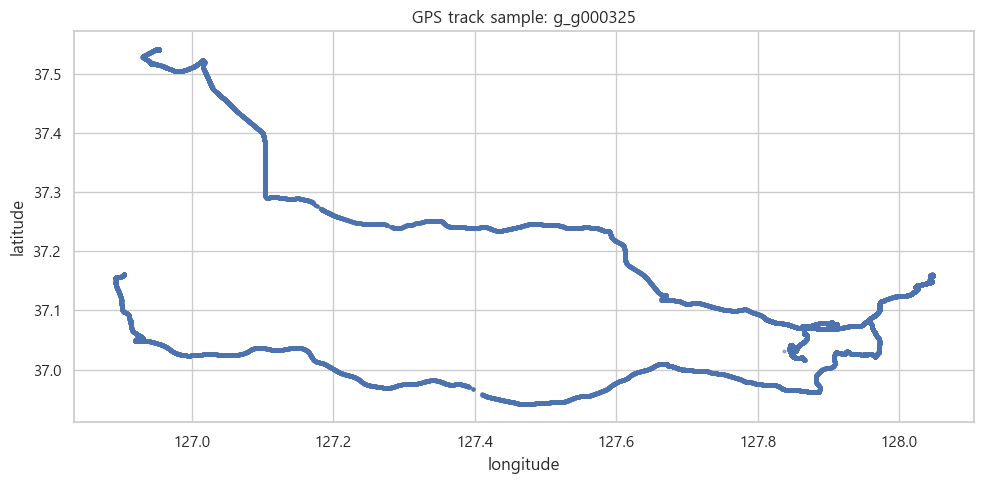

In [22]:
sample_travel_id = gps_track_summary.index[0]
sample_gps = gps[gps["TRAVEL_ID"].eq(sample_travel_id)].sort_values("DT_MIN")

if HAS_PLOT:
    ax = sample_gps.plot.scatter(x="X_COORD", y="Y_COORD", s=4, alpha=0.5, title=f"GPS track sample: {sample_travel_id}")
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    plt.tight_layout()
else:
    sample_gps[["TRAVEL_ID", "DT_MIN", "X_COORD", "Y_COORD"]].head(20)

## 9. 활동과 소비
---
결과
* 식당/카페-취식이 873건 > 숙소-휴식 > 역/터미널-환승/경유 > 상업지구-쇼핑 > 자연관광지-산책/걷기
* 활동 소비 총액은 식당/카페가 약 2,926만 > 상업지구 약 792만 원 > 테마시설 약 294만 
* 이동수단 소비는 자가용이 약 1,151만 원 > KTX/SRT, 렌터카, 버스+지하철, 택시
---
해석
* 사람들은 식당/카페에 가장 소비 많이 함 
* 자가용 이동이 가장 많고 비용 규모도 큼 


In [23]:
activity = csvs["activity"].copy()
for col in ["TRAVEL_ID", "VISIT_AREA_ID"]:
    activity[col] = normalize_id(activity[col])
activity = add_code_label(activity, "ACTIVITY_TYPE_CD", code_maps["ACT"], "ACTIVITY_TYPE_NM")

activity_visit = activity.merge(
    visit_mart[["TRAVEL_ID", "VISIT_AREA_ID", "VISIT_AREA_TYPE_NM", "VISIT_CHC_REASON_NM", "SIDO_NM"]],
    on=["TRAVEL_ID", "VISIT_AREA_ID"],
    how="left",
)
activity_summary = activity_visit.groupby(["VISIT_AREA_TYPE_NM", "ACTIVITY_TYPE_NM"]).size().rename("n").reset_index()
activity_summary.sort_values("n", ascending=False).head(30)

,VISIT_AREA_TYPE_NM,ACTIVITY_TYPE_NM,n
48,식당/카페,취식,873
46,숙소,휴식,245
56,"역, 터미널, 고속도로 휴게소",환승/경유,191
28,"상업지구(거리, 시장, 쇼핑시설)",쇼핑 / 구매,181
66,자연관광지,단순 구경 / 산책 / 걷기,167
59,"역사/유적/종교 시설(문화재, 박물관, 촬영지, 절 등)",단순 구경 / 산책 / 걷기,149
61,"역사/유적/종교 시설(문화재, 박물관, 촬영지, 절 등)",체험 활동 / 입장 및 관람,147
30,"상업지구(거리, 시장, 쇼핑시설)",취식,118
49,식당/카페,휴식,116
27,"상업지구(거리, 시장, 쇼핑시설)",단순 구경 / 산책 / 걷기,107


In [24]:
activity_consume = csvs["activity_consume"].copy()
for col in ["TRAVEL_ID", "VISIT_AREA_ID"]:
    activity_consume[col] = normalize_id(activity_consume[col])
activity_consume["PAYMENT_AMT_WON"] = numeric_series(activity_consume["PAYMENT_AMT_WON"])

consume_visit = activity_consume.merge(
    visit_mart[["TRAVEL_ID", "VISIT_AREA_ID", "VISIT_AREA_TYPE_NM", "VISIT_CHC_REASON_NM", "SIDO_NM"]],
    on=["TRAVEL_ID", "VISIT_AREA_ID"],
    how="left",
)

consume_by_type = consume_visit.groupby("VISIT_AREA_TYPE_NM").agg(
    payments=("PAYMENT_AMT_WON", "count"),
    total_won=("PAYMENT_AMT_WON", "sum"),
    median_won=("PAYMENT_AMT_WON", "median"),
    mean_won=("PAYMENT_AMT_WON", "mean"),
).sort_values("total_won", ascending=False)
consume_by_type.head(15)

,payments,total_won,median_won,mean_won
VISIT_AREA_TYPE_NM,,,,
식당/카페,971,29260540,21000.0,30134.438723
"상업지구(거리, 시장, 쇼핑시설)",286,7917116,12900.0,27682.223776
"테마시설(놀이공원, 워터파크)",69,2936425,19000.0,42556.884058
상점,84,2401932,17375.0,28594.428571
체험 활동 관광지,87,2220637,16000.0,25524.563218
숙소,89,1933130,10980.0,21720.561798
"역, 터미널, 고속도로 휴게소",141,1430330,6500.0,10144.184397
자연관광지,93,1314680,6400.0,14136.344086
"레저/스포츠 관련 시설(스키, 카트, 수상레저)",30,1017700,16000.0,33923.333333


In [25]:
movement_consume = csvs["movement_consume"].copy()
movement_consume["PAYMENT_AMT_WON"] = numeric_series(movement_consume["PAYMENT_AMT_WON"])
movement_consume.groupby("MVMN_SE_NM").agg(
    payments=("PAYMENT_AMT_WON", "count"),
    total_won=("PAYMENT_AMT_WON", "sum"),
    median_won=("PAYMENT_AMT_WON", "median"),
).sort_values("total_won", ascending=False)

,payments,total_won,median_won
MVMN_SE_NM,,,
자가용(승용/승합/트럭 등등),390,11506898,20000.0
KTX/SRT(고속열차),54,2099100,23700.0
렌터카(승용/승합/버스 등등),30,1544308,20999.5
버스 + 지하철,28,1021660,32375.0
택시,87,988566,7700.0
시외/고속버스,22,691050,29250.0
새마을/무궁화열차,38,535700,9800.0
항공기,1,236000,236000.0
시내/마을버스,23,179300,4800.0


## 10. 사진 데이터와 방문지 기록 밀도
---
결과
* 방문당 사진 수는 산책로/둘레길, 자연관광지, 역사/유적/종교 시설이 높음
* 식당/카페는 방문 수는 많지만 사진 찍는 비율은 낮음 
---
해석
* 사진 == 기억에 남는 관광 경험? -> 만약 사진 찍는 기능을 추가할 예정이라면 식당/카페보다 산책로/둘레길, 자연관광지, 역사/유적/종교 시설에 부여해야 함

In [26]:
photo = csvs["photo"].copy()
for col in ["TRAVEL_ID", "VISIT_AREA_ID"]:
    photo[col] = normalize_id(photo[col])

photo_by_visit = photo.groupby(["TRAVEL_ID", "VISIT_AREA_ID"]).size().rename("PHOTO_COUNT").reset_index()
visit_photo = visit_mart.merge(photo_by_visit, on=["TRAVEL_ID", "VISIT_AREA_ID"], how="left")
visit_photo["PHOTO_COUNT"] = visit_photo["PHOTO_COUNT"].fillna(0).astype(int)

visit_photo.groupby("VISIT_AREA_TYPE_NM").agg(
    visits=("VISIT_AREA_ID", "count"),
    avg_photos=("PHOTO_COUNT", "mean"),
    photo_visits=("PHOTO_COUNT", lambda s: int((s > 0).sum())),
).sort_values("avg_photos", ascending=False).head(15)

,visits,avg_photos,photo_visits
VISIT_AREA_TYPE_NM,,,
"산책로, 둘레길 등",86,2.023256,69
자연관광지,216,1.814815,145
"역사/유적/종교 시설(문화재, 박물관, 촬영지, 절 등)",252,1.813492,163
"테마시설(놀이공원, 워터파크)",54,1.481481,28
체험 활동 관광지,88,1.181818,46
"문화 시설(공연장, 영화관, 전시관 등)",112,0.982143,54
지역 축제/행사,32,0.843750,14
"레저/스포츠 관련 시설(스키, 카트, 수상레저)",29,0.724138,13
"상업지구(거리, 시장, 쇼핑시설)",289,0.359862,55


## 11. 인사이트 정리
* 많이 간 곳은 식당/카페, 집, 교통 거점
* 선택 이유는 명소성, 온라인 평가, 우연, 교통 편의
* 만족도 높은 곳은 산책로, 축제, 체험, 자연관광지 쪽

In [27]:
top_type = visit_mart["VISIT_AREA_TYPE_NM"].dropna().value_counts().head(5)
top_reason = visit_mart["VISIT_CHC_REASON_NM"].dropna().value_counts().head(5)
top_region = visit_mart["SIDO_NM"].dropna().value_counts().head(5)
satisfaction_by_type = score_by_type.dropna(subset=["avg_satisfaction"]).sort_values("avg_satisfaction", ascending=False).head(5)

print("[많이 선택된 방문지 유형]")
print(top_type.to_string())
print("\n[주요 선택 이유]")
print(top_reason.to_string())
print("\n[주요 방문 지역]")
print(top_region.to_string())
print("\n[평균 만족도가 높은 방문지 유형]")
print(satisfaction_by_type[["visits", "avg_satisfaction", "avg_recommend"]].to_string())

[많이 선택된 방문지 유형]
VISIT_AREA_TYPE_NM
식당/카페                 924
집                     585
역, 터미널, 고속도로 휴게소      346
상업지구(거리, 시장, 쇼핑시설)    289
숙소                    275

[주요 선택 이유]
VISIT_CHC_REASON_NM
지명도/명소/핫플레이스               684
온라인(SNS, 블로그 등) 평가가 좋아서    661
지나가다 우연히                   359
가기 편해서/교통이 좋아서             319
과거 경험이 좋아서                 191

[주요 방문 지역]
SIDO_NM
경기도      120
서울특별시    107
광주광역시     84
전라북도      83
전라남도      75

[평균 만족도가 높은 방문지 유형]
                    visits  avg_satisfaction  avg_recommend
VISIT_AREA_TYPE_NM                                         
산책로, 둘레길 등              86          4.453488       4.290698
친구/친지집                 104          4.400000       3.800000
지역 축제/행사                32          4.375000       4.531250
체험 활동 관광지               88          4.363636       4.272727
자연관광지                  216          4.356481       4.310185


## 12. 콜드스타트 추천 가능성 진단

- 프로필 기반 콜드스타트: 성별, 연령대, 거주지, 소득, 동반자 수, 여행동기, 여행스타일, 선호 지역 같은 사전 입력이 있는 경우
- 완전 콜드스타트: 아무 입력이 없어 전체 인기 방문지 유형/지역/여정 패턴만 사용할 수 있는 경우

-> 인기 기반으로 구현은 가능하다 .. 뭐 그런데 당연히 프로필 기반이 더 겠지..


In [28]:
def profile_segment_key(df: pd.DataFrame, cols: list[str]) -> pd.Series:
    if not cols:
        return pd.Series("ALL", index=df.index, dtype="string")
    values = []
    for col in cols:
        if col in df.columns:
            values.append(df[col].astype("string").fillna("UNKNOWN"))
        else:
            values.append(pd.Series("UNKNOWN", index=df.index, dtype="string"))
    return pd.concat(values, axis=1).agg("|".join, axis=1)


def coverage_summary(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    rows = []
    for col in cols:
        if col not in df.columns:
            rows.append({"column": col, "available_rows": 0, "coverage_rate": 0.0, "n_unique": 0})
            continue
        non_missing = df[col].notna() & df[col].astype("string").str.strip().ne("")
        rows.append({
            "column": col,
            "available_rows": int(non_missing.sum()),
            "coverage_rate": round(float(non_missing.mean()), 3),
            "n_unique": int(df.loc[non_missing, col].nunique()),
        })
    return pd.DataFrame(rows).sort_values("coverage_rate", ascending=False)


def topk_by_segment(
    df: pd.DataFrame,
    segment_cols: list[str],
    target_col: str,
    k: int = 5,
    min_segment_size: int = 5,
) -> pd.DataFrame:
    needed = [col for col in segment_cols + [target_col] if col in df.columns]
    work = df[needed].dropna(subset=[target_col]).copy()
    if work.empty:
        return pd.DataFrame(columns=["segment_key", "rank", target_col, "count", "segment_size"])
    work["segment_key"] = profile_segment_key(work, segment_cols)
    segment_sizes = work.groupby("segment_key")[target_col].size().rename("segment_size")
    counts = work.groupby(["segment_key", target_col]).size().rename("count").reset_index()
    counts = counts.merge(segment_sizes, on="segment_key", how="left")
    counts = counts[counts["segment_size"].ge(min_segment_size)].copy()
    if counts.empty:
        return pd.DataFrame(columns=["segment_key", "rank", target_col, "count", "segment_size"])
    counts["rank"] = counts.groupby("segment_key")["count"].rank(method="first", ascending=False).astype(int)
    return counts[counts["rank"].le(k)].sort_values(["segment_key", "rank"])


def hit_rate_at_k(actual_df: pd.DataFrame, recommendation_df: pd.DataFrame, user_col: str, target_col: str, k: int = 5) -> float:
    if actual_df.empty or recommendation_df.empty:
        return np.nan
    recs = recommendation_df[recommendation_df["rank"].le(k)].groupby(user_col)[target_col].apply(set)
    actuals = actual_df.groupby(user_col)[target_col].apply(lambda s: set(s.dropna()))
    common_users = actuals.index.intersection(recs.index)
    if len(common_users) == 0:
        return np.nan
    hits = [bool(actuals.loc[user] & recs.loc[user]) for user in common_users]
    return round(float(np.mean(hits)), 3)


def leave_one_traveler_recommendations(
    df: pd.DataFrame,
    user_col: str,
    segment_cols: list[str],
    target_col: str,
    k: int = 5,
    min_segment_size: int = 5,
) -> pd.DataFrame:
    base = df.dropna(subset=[user_col, target_col]).copy()
    base["segment_key"] = profile_segment_key(base, segment_cols)
    global_top = base[target_col].value_counts().head(k).index.tolist()
    rows = []
    for user, user_rows in base.groupby(user_col):
        segment_key = user_rows["segment_key"].iloc[0]
        pool = base[base[user_col].ne(user)]
        segment_pool = pool[pool["segment_key"].eq(segment_key)]
        if len(segment_pool) >= min_segment_size:
            candidates = segment_pool[target_col].value_counts().head(k).index.tolist()
            source = "profile_segment"
        else:
            candidates = pool[target_col].value_counts().head(k).index.tolist() or global_top
            source = "global_fallback"
        for rank, value in enumerate(candidates[:k], start=1):
            rows.append({user_col: user, "segment_key": segment_key, "rank": rank, target_col: value, "source": source})
    return pd.DataFrame(rows)


In [29]:
cold_start_cols = [
    "GENDER", "AGE_GRP", "RESIDENCE_SGG_CD", "INCOME", "HOUSE_INCOME", "TRAVEL_COMPANIONS_NUM",
    "TRAVEL_LIKE_SIDO_1", "TRAVEL_LIKE_SGG_1", "TRAVEL_LIKE_SIDO_2", "TRAVEL_LIKE_SGG_2", "TRAVEL_LIKE_SIDO_3", "TRAVEL_LIKE_SGG_3",
    "TRAVEL_STYL_1", "TRAVEL_STYL_2", "TRAVEL_STYL_3", "TRAVEL_STYL_4", "TRAVEL_STYL_5", "TRAVEL_STYL_6", "TRAVEL_STYL_7", "TRAVEL_STYL_8",
    "TRAVEL_MOTIVE_1", "TRAVEL_MOTIVE_2", "TRAVEL_MOTIVE_3", "TRAVEL_PURPOSE",
]

coverage = coverage_summary(visit_mart, cold_start_cols)
coverage


,column,available_rows,coverage_rate,n_unique
0,GENDER,3554,1.000,2
11,TRAVEL_LIKE_SGG_3,3554,1.000,104
20,TRAVEL_MOTIVE_1,3554,1.000,10
19,TRAVEL_STYL_8,3554,1.000,7
18,TRAVEL_STYL_7,3554,1.000,7
17,TRAVEL_STYL_6,3554,1.000,7
16,TRAVEL_STYL_5,3554,1.000,7
15,TRAVEL_STYL_4,3554,1.000,7
14,TRAVEL_STYL_3,3554,1.000,7
13,TRAVEL_STYL_2,3554,1.000,7


In [30]:
cold_start_mart = visit_mart.copy()
for col, cmap, label_col in [
    ("GENDER", code_maps["GEN"], "GENDER_NM"),
    ("AGE_GRP", code_maps["AGE"], "AGE_GRP_NM"),
    ("INCOME", code_maps["INC"], "INCOME_NM"),
    ("HOUSE_INCOME", code_maps["INC"], "HOUSE_INCOME_NM"),
    ("EDU_NM", code_maps["EDU"], "EDU_LABEL"),
    ("MARR_STTS", code_maps["MAR"], "MARR_STTS_NM"),
    ("JOB_NM", code_maps["JOB"], "JOB_LABEL"),
    ("TRAVEL_MOTIVE_1", code_maps["TMT"], "TRAVEL_MOTIVE_1_NM"),
    ("TRAVEL_MOTIVE_2", code_maps["TMT"], "TRAVEL_MOTIVE_2_NM"),
    ("TRAVEL_MOTIVE_3", code_maps["TMT"], "TRAVEL_MOTIVE_3_NM"),
]:
    cold_start_mart = add_code_label(cold_start_mart, col, cmap, label_col)

segment_cols = ["AGE_GRP", "GENDER", "TRAVEL_COMPANIONS_NUM"]
preference_cols = ["TRAVEL_MOTIVE_1", "TRAVEL_STYL_1", "TRAVEL_LIKE_SIDO_1"]

segment_profile = cold_start_mart[["TRAVELER_ID"] + segment_cols + preference_cols].drop_duplicates("TRAVELER_ID")
segment_profile.assign(segment_key=profile_segment_key(segment_profile, segment_cols)).head(10)


,TRAVELER_ID,AGE_GRP,GENDER,TRAVEL_COMPANIONS_NUM,TRAVEL_MOTIVE_1,TRAVEL_STYL_1,TRAVEL_LIKE_SIDO_1,segment_key
0,e000658,30,남,5,9,4,29,30|남|5
15,e001224,30,여,0,5,3,47,30|여|0
42,e001941,50,여,4,7,7,42,50|여|4
49,e003599,20,여,0,1,5,11,20|여|0
60,e013081,30,남,1,2,6,41,30|남|1
72,f016829,20,여,1,1,3,48,20|여|1
78,g000006,40,남,1,2,1,41,40|남|1
92,g000028,40,여,4,2,1,42,40|여|4
101,g000213,30,남,1,2,2,50,30|남|1
108,g000217,30,남,1,2,2,42,30|남|1


In [31]:
segment_type_top = topk_by_segment(cold_start_mart, segment_cols, "VISIT_AREA_TYPE_NM", k=5, min_segment_size=10)
segment_reason_top = topk_by_segment(cold_start_mart, segment_cols, "VISIT_CHC_REASON_NM", k=5, min_segment_size=10)
segment_region_top = topk_by_segment(cold_start_mart, segment_cols, "SIDO_NM", k=5, min_segment_size=10)

segment_quality = (
    cold_start_mart.assign(segment_key=profile_segment_key(cold_start_mart, segment_cols))
    .groupby("segment_key")
    .agg(
        visits=("VISIT_AREA_ID", "count"),
        travelers=("TRAVELER_ID", "nunique"),
        avg_satisfaction=("DGSTFN", "mean"),
        avg_recommend=("RCMDTN_INTENTION", "mean"),
        top_type=("VISIT_AREA_TYPE_NM", lambda s: s.dropna().mode().iat[0] if not s.dropna().mode().empty else np.nan),
        top_reason=("VISIT_CHC_REASON_NM", lambda s: s.dropna().mode().iat[0] if not s.dropna().mode().empty else np.nan),
    )
    .sort_values(["travelers", "visits"], ascending=False)
)

segment_quality.head(15)


,visits,travelers,avg_satisfaction,avg_recommend,top_type,top_reason
segment_key,,,,,,
20|여|1,364,34,4.362712,4.271186,식당/카페,지명도/명소/핫플레이스
20|남|1,325,26,4.147170,4.022642,식당/카페,지명도/명소/핫플레이스
20|여|0,308,26,4.340000,4.232000,식당/카페,가기 편해서/교통이 좋아서
30|여|1,237,23,4.126316,3.947368,식당/카페,지명도/명소/핫플레이스
30|남|1,230,20,4.505376,4.381720,식당/카페,"온라인(SNS, 블로그 등) 평가가 좋아서"
40|남|1,180,17,4.187500,4.055556,식당/카페,지명도/명소/핫플레이스
30|여|0,206,16,4.175758,4.084848,식당/카페,"온라인(SNS, 블로그 등) 평가가 좋아서"
40|여|1,141,13,4.226087,4.069565,식당/카페,"온라인(SNS, 블로그 등) 평가가 좋아서"
30|남|2,84,9,4.555556,4.380952,집,"온라인(SNS, 블로그 등) 평가가 좋아서"


In [32]:
type_recs = leave_one_traveler_recommendations(
    cold_start_mart,
    user_col="TRAVELER_ID",
    segment_cols=segment_cols,
    target_col="VISIT_AREA_TYPE_NM",
    k=5,
    min_segment_size=10,
)
region_recs = leave_one_traveler_recommendations(
    cold_start_mart,
    user_col="TRAVELER_ID",
    segment_cols=segment_cols,
    target_col="SIDO_NM",
    k=5,
    min_segment_size=10,
)

actual_type = cold_start_mart[["TRAVELER_ID", "VISIT_AREA_TYPE_NM"]].dropna().drop_duplicates()
actual_region = cold_start_mart[["TRAVELER_ID", "SIDO_NM"]].dropna().drop_duplicates()

global_type_recs = pd.DataFrame([
    {"TRAVELER_ID": user, "rank": rank, "VISIT_AREA_TYPE_NM": value, "source": "global_only"}
    for user in actual_type["TRAVELER_ID"].unique()
    for rank, value in enumerate(cold_start_mart["VISIT_AREA_TYPE_NM"].dropna().value_counts().head(5).index, start=1)
])
global_region_recs = pd.DataFrame([
    {"TRAVELER_ID": user, "rank": rank, "SIDO_NM": value, "source": "global_only"}
    for user in actual_region["TRAVELER_ID"].unique()
    for rank, value in enumerate(cold_start_mart["SIDO_NM"].dropna().value_counts().head(5).index, start=1)
])

cold_start_eval = pd.DataFrame([
    {"target": "방문지 유형", "strategy": "profile segment + fallback", "hit_rate_at_5": hit_rate_at_k(actual_type, type_recs, "TRAVELER_ID", "VISIT_AREA_TYPE_NM", k=5), "fallback_share": round(float(type_recs["source"].eq("global_fallback").mean()), 3)},
    {"target": "방문지 유형", "strategy": "global popularity only", "hit_rate_at_5": hit_rate_at_k(actual_type, global_type_recs, "TRAVELER_ID", "VISIT_AREA_TYPE_NM", k=5), "fallback_share": 1.0},
    {"target": "방문 지역", "strategy": "profile segment + fallback", "hit_rate_at_5": hit_rate_at_k(actual_region, region_recs, "TRAVELER_ID", "SIDO_NM", k=5), "fallback_share": round(float(region_recs["source"].eq("global_fallback").mean()), 3)},
    {"target": "방문 지역", "strategy": "global popularity only", "hit_rate_at_5": hit_rate_at_k(actual_region, global_region_recs, "TRAVELER_ID", "SIDO_NM", k=5), "fallback_share": 1.0},
])

cold_start_eval


,target,strategy,hit_rate_at_5,fallback_share
0,방문지 유형,profile segment + fallback,1.000,0.056
1,방문지 유형,global popularity only,1.000,1.000
2,방문 지역,profile segment + fallback,0.649,0.325
3,방문 지역,global popularity only,0.727,1.000


In [33]:
route_template = order_summary.head(8).reset_index().rename(columns={"VISIT_ORDER": "visit_order"})
activity_template = activity_summary.sort_values("n", ascending=False).head(10)
consume_template = consume_by_type.head(10).reset_index()
photo_template = (
    visit_photo.groupby("VISIT_AREA_TYPE_NM")
    .agg(visits=("VISIT_AREA_ID", "count"), avg_photos=("PHOTO_COUNT", "mean"), photo_visits=("PHOTO_COUNT", lambda s: int((s > 0).sum())))
    .sort_values("avg_photos", ascending=False)
    .head(10)
    .reset_index()
)

print("[방문 순서 기반 여행 계획 템플릿]")
print(route_template[["visit_order", "visits", "top_type", "avg_stay_min"]].to_string(index=False))
print()
print("[활동이 많이 관측된 방문지 유형/활동]")
print(activity_template.to_string(index=False))
print()
print("[소비가 많이 발생한 방문지 유형]")
print(consume_template[["VISIT_AREA_TYPE_NM", "payments", "total_won", "median_won"]].to_string(index=False))
print()
print("[사진 기록 밀도가 높은 방문지 유형]")
print(photo_template.to_string(index=False))


[방문 순서 기반 여행 계획 템플릿]
 visit_order  visits         top_type  avg_stay_min
           1     320                집           NaN
           2     320 역, 터미널, 고속도로 휴게소     65.156250
           3     320            식당/카페     69.750000
           4     315            식당/카페    102.857143
           5     307            식당/카페    116.188925
           6     279            식당/카페    114.516129
           7     249            식당/카페    115.180723
           8     216            식당/카페    116.111111

[활동이 많이 관측된 방문지 유형/활동]
             VISIT_AREA_TYPE_NM ACTIVITY_TYPE_NM   n
                          식당/카페               취식 873
                             숙소               휴식 245
               역, 터미널, 고속도로 휴게소            환승/경유 191
             상업지구(거리, 시장, 쇼핑시설)          쇼핑 / 구매 181
                          자연관광지  단순 구경 / 산책 / 걷기 167
역사/유적/종교 시설(문화재, 박물관, 촬영지, 절 등)  단순 구경 / 산책 / 걷기 149
역사/유적/종교 시설(문화재, 박물관, 촬영지, 절 등)  체험 활동 / 입장 및 관람 147
             상업지구(거리, 시장, 쇼핑시설)               취식 118
          

In [34]:
high_coverage = coverage[coverage["coverage_rate"].ge(0.8)]["column"].tolist()
best_type_strategy = cold_start_eval[cold_start_eval["target"].eq("방문지 유형")].sort_values("hit_rate_at_5", ascending=False).iloc[0]
best_region_strategy = cold_start_eval[cold_start_eval["target"].eq("방문 지역")].sort_values("hit_rate_at_5", ascending=False).iloc[0]

print("[신규 사용자 입력 신호 커버리지]")
print(f"80% 이상 채워진 신호 수: {len(high_coverage)} / {len(cold_start_cols)}")
print(", ".join(high_coverage[:12]))
print()
print("[오프라인 Top-5 적중률 비교]")
print(cold_start_eval.to_string(index=False))
print()
print("[판단]")
print(f"방문지 유형 추천은 '{best_type_strategy['strategy']}' 전략이 Top-5 hit rate {best_type_strategy['hit_rate_at_5']}로 가장 높습니다.")
print(f"방문 지역 추천은 '{best_region_strategy['strategy']}' 전략이 Top-5 hit rate {best_region_strategy['hit_rate_at_5']}로 가장 높습니다.")
print("프로필 세그먼트의 fallback 비중이 높으면 샘플 수가 부족하다는 뜻이므로, 실제 서비스에서는 온보딩 질문을 줄이거나 더 큰 학습 데이터를 확보해야 합니다.")
print("완전 콜드스타트는 전체 인기 유형/지역과 방문 순서 템플릿으로 시작하고, 프로필 기반 콜드스타트는 연령대, 성별, 동반자 수, 여행동기/스타일/선호지역 입력을 받아 후보를 좁히는 방식이 적합합니다.")


[신규 사용자 입력 신호 커버리지]
80% 이상 채워진 신호 수: 23 / 24
GENDER, TRAVEL_LIKE_SGG_3, TRAVEL_MOTIVE_1, TRAVEL_STYL_8, TRAVEL_STYL_7, TRAVEL_STYL_6, TRAVEL_STYL_5, TRAVEL_STYL_4, TRAVEL_STYL_3, TRAVEL_STYL_2, AGE_GRP, TRAVEL_STYL_1

[오프라인 Top-5 적중률 비교]
target                   strategy  hit_rate_at_5  fallback_share
방문지 유형 profile segment + fallback          1.000           0.056
방문지 유형     global popularity only          1.000           1.000
 방문 지역 profile segment + fallback          0.649           0.325
 방문 지역     global popularity only          0.727           1.000

[판단]
방문지 유형 추천은 'profile segment + fallback' 전략이 Top-5 hit rate 1.0로 가장 높습니다.
방문 지역 추천은 'global popularity only' 전략이 Top-5 hit rate 0.727로 가장 높습니다.
프로필 세그먼트의 fallback 비중이 높으면 샘플 수가 부족하다는 뜻이므로, 실제 서비스에서는 온보딩 질문을 줄이거나 더 큰 학습 데이터를 확보해야 합니다.
완전 콜드스타트는 전체 인기 유형/지역과 방문 순서 템플릿으로 시작하고, 프로필 기반 콜드스타트는 연령대, 성별, 동반자 수, 여행동기/스타일/선호지역 입력을 받아 후보를 좁히는 방식이 적합합니다.


## 13. 콜드스타트 온보딩 입력 항목 선정
---
종료
- 1단계 필수: AGE_GRP, GENDER, TRAVEL_COMPANIONS_NUM, TRAVEL_PURPOSE
- 2단계 개선: RESIDENCE_SGG_CD, TRAVEL_LIKE_SIDO_1, TRAVEL_LIKE_SGG_1, TRAVEL_MOTIVE_1, TRAVEL_STYL_1
- 3단계 보류: INCOME, HOUSE_INCOME, TRAVEL_NUM, TRAVEL_TERM
---
정리

[1] 인구통계학적 특성 (Demographics)
- 연령대 (AGE_GRP) : 20, 30, 40, 50, 60
- 성별 (GENDER) : 남, 여
- 거주 지역 (RESIDENCE_SGG_CD) : 11(서울), 26(부산), 27(대구), 28(인천), 29(광주), 30(대전), 36(세종), 41(경기), 42(강원), 43(충북), 44(충남), 45(전북), 46(전남), 47(경북), 48(경남)

[2] 여행 동반 및 목적 (Companions & Motivation)
- 동반자 수 (TRAVEL_COMPANIONS_NUM) : 0, 1, 2, 3, 4, 5, 6, 7, 9
- 주요 여행 동기 (TRAVEL_MOTIVE_1) : 1(일탈/지루함 탈피), 2(휴식), 3(유대감 증진), 4(자아 찾기), 5(SNS 과시), 6(운동/건강), 7(새로운 경험), 8(역사/문화 교육), 9(특별 목적), 10(기타)
- 이번 여행 목적 (TRAVEL_PURPOSE) : 1, 10;21, 11;22 등 총 286개 조합 (세미콜론 ';' 기준 분리 필요)

[3] 여행 스타일 (Travel Style)
- 대표 여행 스타일 (TRAVEL_STYL_1) : 
  1 (자연 매우 선호)
  2 (자연 중간 선호)
  3 (자연 약간 선호)
  4 (중립)
  5 (도시 약간 선호)
  6 (도시 중간 선호)
  7 (도시 매우 선호)

[4] 선호 여행 지역 (Preferred Destinations)
- 선호 여행 시도 (TRAVEL_LIKE_SIDO_1) : 11(서울), 26(부산), 27(대구), 28(인천), 29(광주), 30(대전), 31(울산), 41(경기), 42(강원), 43(충북), 44(충남), 45(전북), 46(전남), 47(경북), 48(경남), 50(제주)
- 선호 여행 시군구 (TRAVEL_LIKE_SGG_1) : 11110(서울 종로구), 26110(부산 중구) 등 총 82개 
  (※ 41270, 41460, 44130, 45110 등 라벨 값 누락 데이터 포함)


In [35]:
def _mutual_information(x: pd.Series, y: pd.Series) -> float:
    pair = pd.DataFrame({"x": x.astype("string"), "y": y.astype("string")}).dropna()
    if pair.empty:
        return np.nan
    joint = pair.value_counts(normalize=True)
    px = pair["x"].value_counts(normalize=True)
    py = pair["y"].value_counts(normalize=True)
    score = 0.0
    for (x_val, y_val), p_xy in joint.items():
        score += p_xy * np.log(p_xy / (px.loc[x_val] * py.loc[y_val]))
    return float(score)


def _question_cost(col: str, n_unique: int) -> int:
    if col in {"INCOME", "HOUSE_INCOME"}:
        return 4
    if col in {"TRAVEL_LIKE_SGG_1", "TRAVEL_LIKE_SGG_2", "TRAVEL_LIKE_SGG_3", "TRAVEL_PURPOSE"}:
        return 3
    if col.startswith("TRAVEL_STYL_") or col.startswith("TRAVEL_MOTIVE_"):
        return 2
    if n_unique > 20:
        return 3
    return 1


def profile_signal_summary(df: pd.DataFrame, candidate_cols: list[str], target_cols: dict[str, str]) -> pd.DataFrame:
    rows = []
    for col in candidate_cols:
        if col not in df.columns:
            rows.append({"signal": col, "coverage_rate": 0.0, "n_unique": 0, "question_cost": 3})
            continue
        x = df[col].astype("string")
        non_missing = x.notna() & x.str.strip().ne("")
        n_unique = int(x[non_missing].nunique())
        row = {
            "signal": col,
            "coverage_rate": round(float(non_missing.mean()), 3),
            "n_unique": n_unique,
            "question_cost": _question_cost(col, n_unique),
        }
        for label, target_col in target_cols.items():
            row[f"mi_{label}"] = round(_mutual_information(x[non_missing], df.loc[non_missing, target_col]), 4) if target_col in df.columns else np.nan
        rows.append(row)
    out = pd.DataFrame(rows)
    mi_cols = [c for c in out.columns if c.startswith("mi_")]
    out["utility_score"] = out[mi_cols].fillna(0).sum(axis=1) / out["question_cost"].clip(lower=1)
    return out.sort_values("utility_score", ascending=False)


def evaluate_profile_set(
    df: pd.DataFrame,
    profile_cols: list[str],
    target_col: str,
    k: int = 5,
    min_segment_size: int = 10,
) -> dict:
    actual = df[["TRAVELER_ID", target_col]].dropna().drop_duplicates()
    recs = leave_one_traveler_recommendations(
        df,
        user_col="TRAVELER_ID",
        segment_cols=profile_cols,
        target_col=target_col,
        k=k,
        min_segment_size=min_segment_size,
    )
    return {
        "target_col": target_col,
        "hit_rate_at_5": hit_rate_at_k(actual, recs, "TRAVELER_ID", target_col, k=k),
        "fallback_share": round(float(recs["source"].eq("global_fallback").mean()), 3) if len(recs) else np.nan,
        "segment_cols": ", ".join(profile_cols) if profile_cols else "GLOBAL_ONLY",
    }


def compare_profile_sets(df: pd.DataFrame, profile_sets: dict[str, list[str]], target_cols: dict[str, str]) -> pd.DataFrame:
    rows = []
    for set_name, cols in profile_sets.items():
        for target_name, target_col in target_cols.items():
            result = evaluate_profile_set(df, cols, target_col, k=5, min_segment_size=10)
            rows.append({"profile_set": set_name, "target": target_name, **result})
    out = pd.DataFrame(rows)
    baselines = out[out["profile_set"].eq("전체 인기 baseline")][["target", "hit_rate_at_5"]].rename(columns={"hit_rate_at_5": "baseline_hit_rate"})
    out = out.merge(baselines, on="target", how="left")
    out["gain_vs_global"] = (out["hit_rate_at_5"] - out["baseline_hit_rate"]).round(3)
    return out.drop(columns=["target_col", "baseline_hit_rate"])


def rank_onboarding_questions(signal_summary: pd.DataFrame, performance_gain: pd.DataFrame) -> pd.DataFrame:
    summary = signal_summary.copy()
    summary["recommended_tier"] = "3단계 보류"
    must_have = {"AGE_GRP", "GENDER", "TRAVEL_COMPANIONS_NUM", "TRAVEL_PURPOSE"}
    improve = {"RESIDENCE_SGG_CD", "TRAVEL_LIKE_SIDO_1", "TRAVEL_LIKE_SGG_1", "TRAVEL_MOTIVE_1", "TRAVEL_STYL_1"}
    sensitive_or_optional = {"INCOME", "HOUSE_INCOME"}
    summary.loc[summary["signal"].isin(must_have), "recommended_tier"] = "1단계 필수"
    summary.loc[summary["signal"].isin(improve) & ~summary["signal"].isin(must_have), "recommended_tier"] = "2단계 개선"
    summary.loc[summary["signal"].isin(sensitive_or_optional), "recommended_tier"] = "3단계 보류"
    summary.loc[(summary["coverage_rate"].lt(0.8)) | (summary["question_cost"].ge(4)), "recommended_tier"] = "3단계 보류"
    tier_order = {"1단계 필수": 0, "2단계 개선": 1, "3단계 보류": 2}
    summary["tier_order"] = summary["recommended_tier"].map(tier_order)
    return summary.sort_values(["tier_order", "utility_score"], ascending=[True, False]).drop(columns=["tier_order"])


In [36]:
cold_start_mart["TRAVEL_PURPOSE_PRIMARY"] = cold_start_mart["TRAVEL_PURPOSE"].astype("string").str.split(";").str[0]

candidate_groups = {
    "필수 최소 입력": ["AGE_GRP", "GENDER", "TRAVEL_COMPANIONS_NUM", "TRAVEL_PURPOSE"],
    "지역 입력": ["RESIDENCE_SGG_CD", "TRAVEL_LIKE_SIDO_1", "TRAVEL_LIKE_SGG_1"],
    "취향 입력": [
        "TRAVEL_MOTIVE_1", "TRAVEL_MOTIVE_2", "TRAVEL_MOTIVE_3",
        "TRAVEL_STYL_1", "TRAVEL_STYL_2", "TRAVEL_STYL_3", "TRAVEL_STYL_4",
        "TRAVEL_STYL_5", "TRAVEL_STYL_6", "TRAVEL_STYL_7", "TRAVEL_STYL_8",
    ],
    "선택 입력": ["INCOME", "HOUSE_INCOME", "TRAVEL_NUM", "TRAVEL_TERM"],
}

candidate_cols = [col for cols in candidate_groups.values() for col in cols]
target_cols = {
    "visit_type": "VISIT_AREA_TYPE_NM",
    "region": "SIDO_NM",
    "reason": "VISIT_CHC_REASON_NM",
}

signal_summary = profile_signal_summary(cold_start_mart, candidate_cols, target_cols)
signal_summary.head(20)


,signal,coverage_rate,n_unique,question_cost,mi_visit_type,mi_region,mi_reason,utility_score
4,RESIDENCE_SGG_CD,1.000,15,1,0.0511,1.3631,0.0485,1.462700
3,TRAVEL_PURPOSE,1.000,286,3,0.6236,1.9341,0.6298,1.062500
5,TRAVEL_LIKE_SIDO_1,1.000,16,1,0.0480,0.4045,0.0521,0.504600
6,TRAVEL_LIKE_SGG_1,1.000,82,3,0.1943,0.8211,0.1870,0.400800
20,TRAVEL_NUM,1.000,11,1,0.0349,0.1459,0.0333,0.214100
2,TRAVEL_COMPANIONS_NUM,1.000,9,1,0.0336,0.1325,0.0387,0.204800
0,AGE_GRP,1.000,5,1,0.0233,0.1045,0.0198,0.147600
7,TRAVEL_MOTIVE_1,1.000,10,2,0.0320,0.1684,0.0354,0.117900
8,TRAVEL_MOTIVE_2,0.962,10,2,0.0360,0.1497,0.0308,0.108250
9,TRAVEL_MOTIVE_3,0.939,10,2,0.0278,0.1572,0.0311,0.108050


In [37]:
profile_base_cols = ["AGE_GRP", "GENDER", "TRAVEL_COMPANIONS_NUM", "TRAVEL_PURPOSE_PRIMARY"]

profile_sets = {
    "전체 인기 baseline": [],
    "최소 입력": profile_base_cols,
    "최소+선호지역": profile_base_cols + ["TRAVEL_LIKE_SIDO_1", "TRAVEL_LIKE_SGG_1"],
    "최소+여행동기": profile_base_cols + ["TRAVEL_MOTIVE_1", "TRAVEL_MOTIVE_2", "TRAVEL_MOTIVE_3"],
    "최소+여행스타일": profile_base_cols + ["TRAVEL_STYL_1", "TRAVEL_STYL_2", "TRAVEL_STYL_3"],
    "전체 후보 입력": ["TRAVEL_PURPOSE_PRIMARY"] + [col for col in candidate_cols if col != "TRAVEL_PURPOSE"],
}

profile_set_eval = compare_profile_sets(cold_start_mart, profile_sets, target_cols)
profile_set_eval.sort_values(["target", "hit_rate_at_5"], ascending=[True, False])


,profile_set,target,hit_rate_at_5,fallback_share,segment_cols,gain_vs_global
5,최소 입력,reason,0.984,0.540,"AGE_GRP, GENDER, TRAVEL_COMPANIONS_NUM, TRAVEL...",0.003
2,전체 인기 baseline,reason,0.981,0.000,GLOBAL_ONLY,0.000
8,최소+선호지역,reason,0.981,0.942,"AGE_GRP, GENDER, TRAVEL_COMPANIONS_NUM, TRAVEL...",0.000
11,최소+여행동기,reason,0.981,0.991,"AGE_GRP, GENDER, TRAVEL_COMPANIONS_NUM, TRAVEL...",0.000
14,최소+여행스타일,reason,0.981,0.994,"AGE_GRP, GENDER, TRAVEL_COMPANIONS_NUM, TRAVEL...",0.000
17,전체 후보 입력,reason,0.981,1.000,"TRAVEL_PURPOSE_PRIMARY, AGE_GRP, GENDER, TRAVE...",0.000
1,전체 인기 baseline,region,0.727,0.000,GLOBAL_ONLY,0.000
7,최소+선호지역,region,0.727,1.000,"AGE_GRP, GENDER, TRAVEL_COMPANIONS_NUM, TRAVEL...",0.000
10,최소+여행동기,region,0.727,1.000,"AGE_GRP, GENDER, TRAVEL_COMPANIONS_NUM, TRAVEL...",0.000
13,최소+여행스타일,region,0.727,1.000,"AGE_GRP, GENDER, TRAVEL_COMPANIONS_NUM, TRAVEL...",0.000


In [38]:
onboarding_rank = rank_onboarding_questions(signal_summary, profile_set_eval)
print("[추천 입력 항목 우선순위]")
print(onboarding_rank[[
    "signal", "coverage_rate", "n_unique", "mi_visit_type", "mi_region", "mi_reason", "question_cost", "utility_score", "recommended_tier"
]].to_string(index=False))

print()
print("[입력 조합별 Top-5 성능 비교]")
print(profile_set_eval[["profile_set", "target", "hit_rate_at_5", "fallback_share", "gain_vs_global"]].to_string(index=False))


[추천 입력 항목 우선순위]
               signal  coverage_rate  n_unique  mi_visit_type  mi_region  mi_reason  question_cost  utility_score recommended_tier
       TRAVEL_PURPOSE          1.000       286         0.6236     1.9341     0.6298              3       1.062500           1단계 필수
TRAVEL_COMPANIONS_NUM          1.000         9         0.0336     0.1325     0.0387              1       0.204800           1단계 필수
              AGE_GRP          1.000         5         0.0233     0.1045     0.0198              1       0.147600           1단계 필수
               GENDER          1.000         2         0.0024     0.0106     0.0019              1       0.014900           1단계 필수
     RESIDENCE_SGG_CD          1.000        15         0.0511     1.3631     0.0485              1       1.462700           2단계 개선
   TRAVEL_LIKE_SIDO_1          1.000        16         0.0480     0.4045     0.0521              1       0.504600           2단계 개선
    TRAVEL_LIKE_SGG_1          1.000        82         0.1943     0

In [39]:
tier_summary = onboarding_rank.groupby("recommended_tier")["signal"].apply(list)

print("[실제 서비스 온보딩 질문안]")
print("1단계 필수 질문")
print("- 연령대: AGE_GRP")
print("- 성별: GENDER")
print("- 동반자 수: TRAVEL_COMPANIONS_NUM")
print("- 이번 여행 목적: TRAVEL_PURPOSE")
print()
print("2단계 개선 질문")
print("- 출발/거주 지역: RESIDENCE_SGG_CD")
print("- 선호 여행 지역: TRAVEL_LIKE_SIDO_1, TRAVEL_LIKE_SGG_1")
print("- 주요 여행 동기: TRAVEL_MOTIVE_1")
print("- 대표 여행 스타일: TRAVEL_STYL_1")
print()
print("3단계 보류 질문")
print("- 소득/가구소득: INCOME, HOUSE_INCOME은 민감하고 HOUSE_INCOME 커버리지가 낮아 초기 필수 질문에서 제외")
print("- 과거 여행빈도/기간: TRAVEL_NUM, TRAVEL_TERM은 서비스 사용 이력처럼 느껴질 수 있어 선택 질문으로만 사용")
print()
print("[요약 판단]")
print("방문지 유형은 전체 인기와 최소 입력 모두 강하게 맞지만, 지역 추천은 선호 지역과 거주지 입력을 받아야 설명력이 생깁니다.")
print("초기 온보딩은 4개 필수 질문으로 시작하고, 추천 품질을 높이는 화면에서 지역 선호와 여행 동기/스타일을 추가로 받는 구성이 적합합니다.")
print("입력 항목을 늘릴수록 세그먼트가 작아져 fallback 비중이 커질 수 있으므로, 실제 추천 구현에서는 최소 입력 세트와 전체 인기 fallback을 함께 유지해야 합니다.")


[실제 서비스 온보딩 질문안]
1단계 필수 질문
- 연령대: AGE_GRP
- 성별: GENDER
- 동반자 수: TRAVEL_COMPANIONS_NUM
- 이번 여행 목적: TRAVEL_PURPOSE

2단계 개선 질문
- 출발/거주 지역: RESIDENCE_SGG_CD
- 선호 여행 지역: TRAVEL_LIKE_SIDO_1, TRAVEL_LIKE_SGG_1
- 주요 여행 동기: TRAVEL_MOTIVE_1
- 대표 여행 스타일: TRAVEL_STYL_1

3단계 보류 질문
- 소득/가구소득: INCOME, HOUSE_INCOME은 민감하고 HOUSE_INCOME 커버리지가 낮아 초기 필수 질문에서 제외
- 과거 여행빈도/기간: TRAVEL_NUM, TRAVEL_TERM은 서비스 사용 이력처럼 느껴질 수 있어 선택 질문으로만 사용

[요약 판단]
방문지 유형은 전체 인기와 최소 입력 모두 강하게 맞지만, 지역 추천은 선호 지역과 거주지 입력을 받아야 설명력이 생깁니다.
초기 온보딩은 4개 필수 질문으로 시작하고, 추천 품질을 높이는 화면에서 지역 선호와 여행 동기/스타일을 추가로 받는 구성이 적합합니다.
입력 항목을 늘릴수록 세그먼트가 작아져 fallback 비중이 커질 수 있으므로, 실제 추천 구현에서는 최소 입력 세트와 전체 인기 fallback을 함께 유지해야 합니다.


In [40]:
stage_1_questions = {
    "연령대": "AGE_GRP",
    "성별": "GENDER",
    "동반자 수": "TRAVEL_COMPANIONS_NUM",
    "이번 여행 목적": "TRAVEL_PURPOSE",
}

stage_2_questions = {
    "출발/거주 지역": "RESIDENCE_SGG_CD",
    "선호 여행 시도": "TRAVEL_LIKE_SIDO_1",
    "선호 여행 시군구": "TRAVEL_LIKE_SGG_1",
    "주요 여행 동기": "TRAVEL_MOTIVE_1",
    "대표 여행 스타일": "TRAVEL_STYL_1",
}

value_label_maps = {
    "AGE_GRP": code_maps.get("AGE", {}),
    "GENDER": code_maps.get("GEN", {}),
    "INCOME": code_maps.get("INC", {}),
    "HOUSE_INCOME": code_maps.get("INC", {}),
    "TRAVEL_MOTIVE_1": code_maps.get("TMT", {}),
    "TRAVEL_STYL_1": code_maps.get("TSY", {}),
}

sido_map = (
    sgg.assign(SGG_CD1=sgg["SGG_CD1"].astype("string"))
    .dropna(subset=["SGG_CD1", "SIDO_NM"])
    .drop_duplicates("SGG_CD1")
    .set_index("SGG_CD1")["SIDO_NM"]
    .to_dict()
)
sgg_map = (
    sgg.assign(SGG_SHORT=sgg["SGG_CD"].astype("string").str[:5])
    .dropna(subset=["SGG_SHORT", "SIDO_NM", "SGG_NM"])
    .drop_duplicates("SGG_SHORT")
    .set_index("SGG_SHORT")
    .apply(lambda row: f"{row['SIDO_NM']} {row['SGG_NM']}", axis=1)
    .to_dict()
)
value_label_maps.update({
    "RESIDENCE_SGG_CD": sido_map,
    "TRAVEL_LIKE_SIDO_1": sido_map,
    "TRAVEL_LIKE_SGG_1": sgg_map,
})

def unique_values_for_question(df: pd.DataFrame, question_name: str, col: str, stage: str) -> pd.DataFrame:
    values = df[col].dropna().map(clean_code_value).astype("string").drop_duplicates().sort_values()
    label_map = value_label_maps.get(col, {})
    return pd.DataFrame({
        "stage": stage,
        "question": question_name,
        "column": col,
        "value": values,
        "label": values.map(label_map).fillna(values),
    }).reset_index(drop=True)

stage_unique_values = pd.concat(
    [unique_values_for_question(cold_start_mart, name, col, "1단계 필수") for name, col in stage_1_questions.items()]
    + [unique_values_for_question(cold_start_mart, name, col, "2단계 개선") for name, col in stage_2_questions.items()],
    ignore_index=True,
)

for (stage, question, col), group in stage_unique_values.groupby(["stage", "question", "column"], sort=False):
    print(f"[{stage}] {question} ({col}) - unique {len(group)}개")
    print(group[["value", "label"]].to_string(index=False))
    print()


[1단계 필수] 연령대 (AGE_GRP) - unique 5개
value label
   20    20
   30    30
   40    40
   50    50
   60    60

[1단계 필수] 성별 (GENDER) - unique 2개
value label
    남     남
    여     여

[1단계 필수] 동반자 수 (TRAVEL_COMPANIONS_NUM) - unique 9개
value label
    0     0
    1     1
    2     2
    3     3
    4     4
    5     5
    6     6
    7     7
    9     9

[1단계 필수] 이번 여행 목적 (TRAVEL_PURPOSE) - unique 286개
                                                value                                                 label
                                                    1                                                     1
                                             10;21;22                                              10;21;22
                                       10;21;22;24;25                                        10;21;22;24;25
                                              10;21;4                                               10;21;4
                                             10;22;23        